<div style="background: linear-gradient(135deg, #1a1a2e 0%, #16213e 50%, #0f3460 100%);
            border-radius: 16px; padding: 48px 40px; text-align: center; margin-bottom: 8px;">
  <h1 style="color: #e2b96f; font-size: 2.2em; margin: 0 0 8px 0; letter-spacing: 1px; word-wrap: break-word;">
    TP Nro. 2 — Control de Rumbo<br>y Reconstrucción de Trayectoria
  </h1>
  <h2 style="color: #a8c6f0; font-size: 1.2em; font-weight: 400; margin: 0 0 24px 0;">
    IOR442 · Sistemas de Control · Dr. Mariano Scaramal
  </h2>
  <hr style="border-color: #e2b96f44; margin: 20px auto; width: 60%;">
  <p style="color: #c9d6e3; font-size: 1em; margin: 0;">
  </p>
</div>

---
##  Imports

In [51]:
import numpy as np
import control as ctrl
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

plt.rcParams.update({
    'figure.facecolor': '#f8f9fa',
    'axes.facecolor':   '#ffffff',
    'axes.edgecolor':   '#cccccc',
    'axes.grid':        True,
    'grid.color':       '#e0e0e0',
    'grid.linestyle':   '--',
    'grid.linewidth':   0.7,
    'font.size':        11,
    'axes.titlesize':   13,
    'axes.labelsize':   11,
    'legend.fontsize':  10,
    'lines.linewidth':  2,
})

COL = {
    'ref':     '#e63946',   # rojo — referencia
    'psi':     '#457b9d',   # azul — ψ / salida
    'v':       '#2196F3',   # azul claro — velocidad lateral v
    'r':       '#FF9800',   # naranja — yaw rate r
    'tau':     '#9c27b0',   # violeta — señal de control τr
    'error':   '#333333',   # negro — error
    'tray':    '#e63946',   # rojo — trayectoria XY
    'start':   '#1565C0',   # azul oscuro — punto inicial
    'end':     '#212121',   # negro — punto final
    'fast':    '#4caf50',   # verde — polos rápidos
}


---
# Parte A — Control de Rumbo con Asignación de Polos

> Se diseña un controlador por realimentación de estados con integrador del error para
> seguir referencias de rumbo **sin error estacionario**.

## A.1 · Modelo en espacio de estados

A partir de las ecuaciones de movimiento del enunciado, con
$\mathbf{x} = [v,\, r,\, \psi]^T$, $u_c = \tau_r$ e $y = \psi$:

$$\dot{\mathbf{x}} = A\mathbf{x} + Bu_c, \qquad y = C\mathbf{x} + Du_c$$

$$A = \begin{pmatrix}-0.25 & -2 & 0\\ 0.08 & -0.35 & 0\\ 0 & 1 & 0\end{pmatrix},\quad
B = \begin{pmatrix}0\\ 0.62\\ 0\end{pmatrix},\quad
C = \begin{pmatrix}0 & 0 & 1\end{pmatrix},\quad D = 0$$

In [52]:
# ── Matrices del sistema original ─────────────────────────────────────────
A = np.array([[-0.25, -2,    0],
              [ 0.08, -0.35, 0],
              [ 0,     1,    0]])

B = np.array([[0   ],
              [0.62],
              [0   ]])

C = np.array([[0, 0, 1]])
D = np.array([[0]])

print("Matriz A:\n", A)
print("\nMatriz B:\n", B)
print("\nMatriz C:", C)
print("Matriz D:", D)

Matriz A:
 [[-0.25 -2.    0.  ]
 [ 0.08 -0.35  0.  ]
 [ 0.    1.    0.  ]]

Matriz B:
 [[0.  ]
 [0.62]
 [0.  ]]

Matriz C: [[0 0 1]]
Matriz D: [[0]]


## A.2 · Controlabilidad del sistema original

Se construye la matriz de controlabilidad $\mathcal{C} = [B,\; AB,\; A^2B]$ y se verifica
que su rango sea igual al número de estados ($n = 3$).

In [53]:
# ── Controlabilidad del sistema original ──────────────────────────────────
Co = ctrl.ctrb(A, B)
rango = np.linalg.matrix_rank(Co)
det   = np.linalg.det(Co)

print(f"Matriz de controlabilidad Co:\n{np.round(Co, 4)}")
print(f"\nRango de Co : {rango}  (necesario: {A.shape[0]})")
print(f"det(Co)     : {det:.6f}")

if rango == A.shape[0]:
    print("\n Sistema CONTROLABLE → se puede diseñar realimentación de estados completa.")
else:
    print("\n Sistema NO controlable.")

Matriz de controlabilidad Co:
[[ 0.     -1.24    0.744 ]
 [ 0.62   -0.217  -0.0233]
 [ 0.      0.62   -0.217 ]]

Rango de Co : 3  (necesario: 3)
det(Co)     : 0.119164

 Sistema CONTROLABLE → se puede diseñar realimentación de estados completa.


## A.3 · Sistema aumentado con integrador del error

Para eliminar el error estacionario ante referencias constantes se agrega el estado integral
$\dot{\xi} = \psi_{\text{ref}} - \psi$.

El vector de estados aumentado es $\mathbf{x}_a = [v,\; r,\; \psi,\; \xi]^T$, y el sistema queda:

$$\dot{\mathbf{x}}_a = A_a\,\mathbf{x}_a + B_a\,\tau_r + E_a\,\psi_{\text{ref}}$$

$$A_a = \begin{pmatrix}A & 0\\ -C & 0\end{pmatrix},\quad
B_a = \begin{pmatrix}B\\ 0\end{pmatrix},\quad
E_a = \begin{pmatrix}0\\ \vdots\\ 1\end{pmatrix}$$

In [54]:
# ── Sistema aumentado ─────────────────────────────────────────────────────
A_ext = np.block([[A,                np.zeros((3, 1))],
                  [-C,               np.zeros((1, 1))]])

B_ext = np.vstack([B, [[0]]])
E_ext = np.array([[0], [0], [0], [1]])          # cómo ingresa ψ_ref al integrador

C_ext = np.hstack([C, np.zeros((1, 1))])
D_ext = D

print("Aa (sistema aumentado):\n", np.round(A_ext, 4))
print("\nBa:\n", B_ext)
print("\nEa:", E_ext.T)
print("\nCa:", C_ext)

Aa (sistema aumentado):
 [[-0.25 -2.    0.    0.  ]
 [ 0.08 -0.35  0.    0.  ]
 [ 0.    1.    0.    0.  ]
 [ 0.    0.   -1.    0.  ]]

Ba:
 [[0.  ]
 [0.62]
 [0.  ]
 [0.  ]]

Ea: [[0 0 0 1]]

Ca: [[0. 0. 1. 0.]]


## A.4 · Controlabilidad del sistema aumentado

Se verifica que $\mathcal{C}_a$ tiene rango 4 para poder asignar los polos arbitrariamente.

In [55]:
# ── Controlabilidad del sistema aumentado ─────────────────────────────────
Co_ext = ctrl.ctrb(A_ext, B_ext)
rango_ext = np.linalg.matrix_rank(Co_ext)
det_ext   = np.linalg.det(Co_ext)

print(f"Rango de Ca : {rango_ext}  (necesario: {A_ext.shape[0]})")
print(f"det(Ca)     : {det_ext:.6f}")

if rango_ext == A_ext.shape[0]:
    print("\n Sistema aumentado CONTROLABLE → asignación de polos arbitraria posible.")
else:
    print("\n Sistema aumentado NO controlable.")

Rango de Ca : 4  (necesario: 4)
det(Ca)     : -0.018470

 Sistema aumentado CONTROLABLE → asignación de polos arbitraria posible.


## A.5 · Diseño del controlador — Asignación de polos

Ley de control: $\tau_r = -K_a\,\mathbf{x}_a = -K_x\,\mathbf{x} - k_i\,\xi$

Polos deseados: $p_1 = -1.5$, $p_2 = -2.0$, $p_3 = -2.5$, $p_4 = -3.0$

In [56]:
# ── Asignación de polos ───────────────────────────────────────────────────
polos_deseados = [-1.5, -2.0, -2.5, -3.0]
K_ext = ctrl.place(A_ext, B_ext, polos_deseados)

Kx = K_ext[0, :3]
Ki = K_ext[0,  3]

print(f"Ka = {np.round(K_ext, 4)}")
print(f"\n  kv = {Kx[0]:.4f}")
print(f"  kr = {Kx[1]:.4f}")
print(f"  kψ = {Kx[2]:.4f}")
print(f"  ki = {Ki:.4f}")

Ka = [[-174.5181   13.5484 -304.8387 -145.1613]]

  kv = -174.5181
  kr = 13.5484
  kψ = -304.8387
  ki = -145.1613


## A.6 · Simulación a lazo cerrado ($T_f = 60\,\text{s}$)

Referencia de rumbo por tramos:

| Intervalo | $\psi_{\text{ref}}$ |
|-----------|----------------------|
| $t < 10$  | $0$ |
| $10 \le t < 25$ | $\pi/6 \approx 0.524$ rad |
| $25 \le t < 40$ | $-\pi/6$ rad |
| $40 \le t \le 60$ | $\pi/3 \approx 1.047$ rad |

In [57]:
# ── Referencia por tramos ─────────────────────────────────────────────────
tramos = [
    (0,  10,  1000, 0),
    (10, 25,  1500, np.pi/6),
    (25, 40,  1500, -np.pi/6),
    (40, 60,  2000, np.pi/3),
]

psi_ref = np.concatenate([np.full(n, ref) for (_, _, n, ref) in tramos])

# ── Función de simulación (reutilizable en Parte A y C) ───────────────────
def simular_sistema(A_a, B_a, C_a, D_a, K, tramos):
    """
    Simula el sistema aumentado a lazo cerrado tramo a tramo.
    Devuelve: t, y (salida), x_a (estados aumentados), tau_r
    """
    Kx_ = K[0, :3]
    Ki_ = K[0, 3]
    Kx_mat = Kx_.reshape(1, -1)

    A_cl = np.block([[A - B @ Kx_mat,   -B * Ki_],
                     [-C,                np.zeros((1, 1))]])
    B_cl = np.vstack([np.zeros((3, 1)), [[1.0]]])
    sys_cl = ctrl.ss(A_cl, B_cl, C_a, D_a)

    t_total, y_total, x_total = [], [], []
    X0 = np.zeros(4)

    for (t_ini, t_fin, n_pts, ref) in tramos:
        t_tramo = np.linspace(t_ini, t_fin, n_pts)
        t_out, y_out, x_out = ctrl.forced_response(sys_cl, T=t_tramo, U=ref, X0=X0, return_x=True)
        t_total.append(t_out)
        y_total.append(y_out)
        x_total.append(x_out)
        X0 = x_out[:, -1]

    t  = np.concatenate(t_total)
    y  = np.concatenate(y_total, axis=-1)
    xa = np.concatenate(x_total, axis=-1)

    # Señal de control
    tau = -(Kx_ @ xa[:3, :]) + Ki_ * xa[3, :]

    return t, y, xa, tau

# ── Simulación con polos originales ───────────────────────────────────────
t1, y1, x1, tau1 = simular_sistema(A_ext, B_ext, C_ext, D_ext, K_ext, tramos)

print(" Simulación completada.")
print(f"   Puntos de tiempo: {len(t1)}")
print(f"   τr_max = {np.max(np.abs(tau1)):.2f}")

 Simulación completada.
   Puntos de tiempo: 6000
   τr_max = 638.45


### Seguimiento de referencia

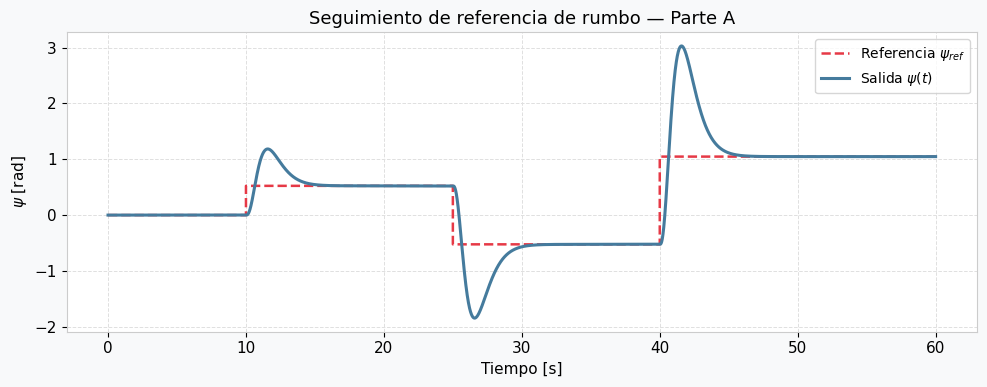

In [58]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(t1, psi_ref, '--', color=COL['ref'],  lw=1.8, label=r'Referencia $\psi_{ref}$')
ax.plot(t1, y1,      '-',  color=COL['psi'],  lw=2.2, label=r'Salida $\psi(t)$')
ax.set_xlabel('Tiempo [s]')
ax.set_ylabel(r'$\psi$ [rad]')
ax.set_title('Seguimiento de referencia de rumbo — Parte A')
ax.legend()
plt.tight_layout()
plt.show()

## A.7 · Error de seguimiento, estados y señal de control

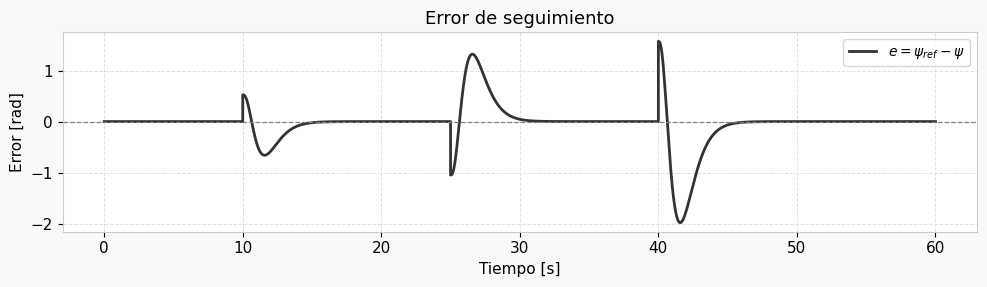

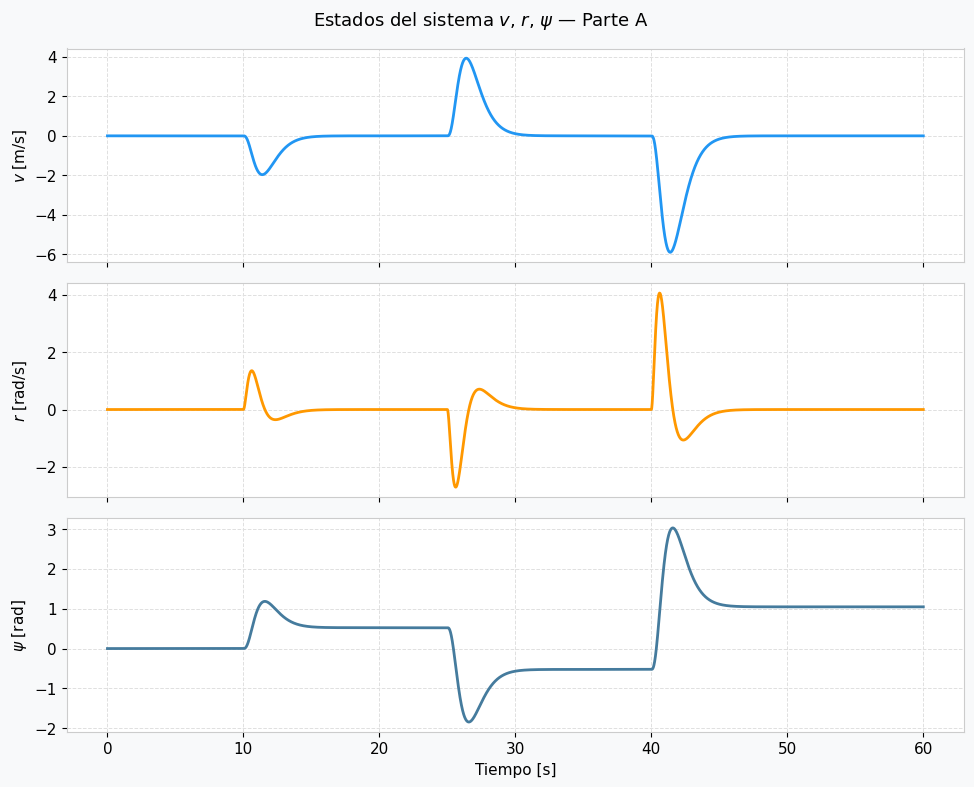

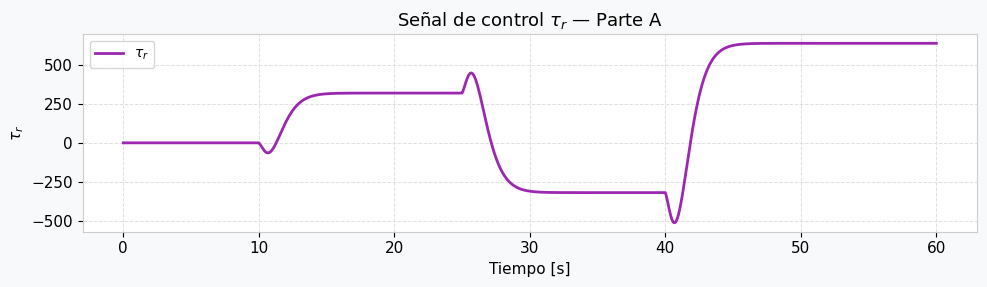

Pico máximo |τr| = 638.45


In [59]:
error1 = psi_ref - y1

# ── Error de seguimiento ──────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(t1, error1, color=COL['error'], label=r'$e = \psi_{ref} - \psi$')
ax.axhline(0, color='gray', lw=0.9, ls='--')
ax.set_xlabel('Tiempo [s]')
ax.set_ylabel('Error [rad]')
ax.set_title('Error de seguimiento')
ax.legend()
plt.tight_layout()
plt.show()

# ── Estados v, r, ψ ──────────────────────────────────────────────────────
labels  = [r'$v$ [m/s]', r'$r$ [rad/s]', r'$\psi$ [rad]']
colores = [COL['v'], COL['r'], COL['psi']]

fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
for i, (lbl, col) in enumerate(zip(labels, colores)):
    axes[i].plot(t1, x1[i], color=col)
    axes[i].set_ylabel(lbl)
axes[-1].set_xlabel('Tiempo [s]')
fig.suptitle(r'Estados del sistema $v$, $r$, $\psi$ — Parte A', fontsize=13)
plt.tight_layout()
plt.show()

# ── Señal de control ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(t1, tau1, color=COL['tau'], label=r'$\tau_r$')
ax.set_xlabel('Tiempo [s]')
ax.set_ylabel(r'$\tau_r$')
ax.set_title(r'Señal de control $\tau_r$ — Parte A')
ax.legend()
plt.tight_layout()
plt.show()

print(f"Pico máximo |τr| = {np.max(np.abs(tau1)):.2f}")

### Comparación con polos más rápidos ($p = [-3,\,-4,\,-5,\,-6]$)

Ka polos originales : [[-174.52   13.55 -304.84 -145.16]]
Ka polos rápidos    : [[-3634.2     28.06 -7083.87 -2322.58]]


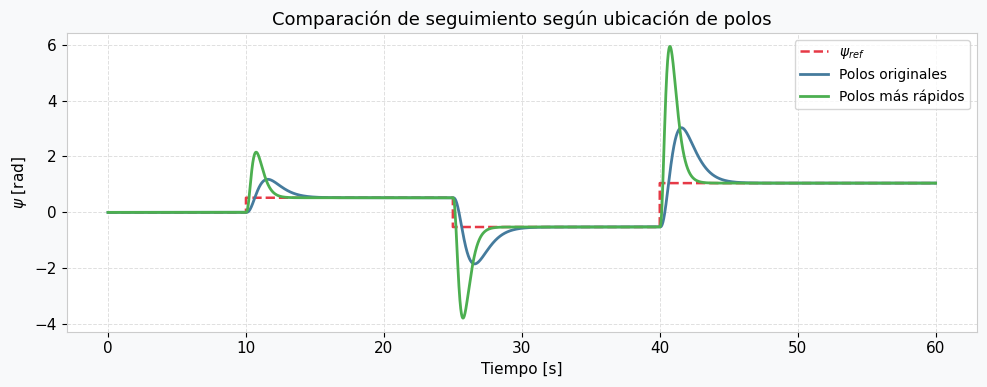

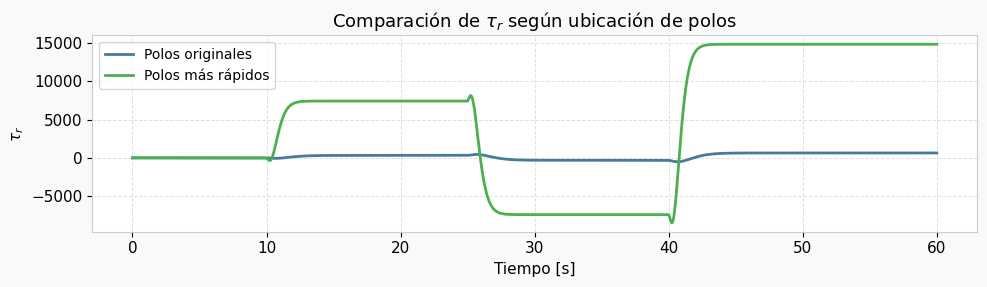


|τr|_max polos originales : 638.45
|τr|_max polos rápidos    : 14836.42


In [60]:
polos_rapidos = [-3.0, -4.0, -5.0, -6.0]
K_rap = ctrl.place(A_ext, B_ext, polos_rapidos)
t2, y2, x2, tau2 = simular_sistema(A_ext, B_ext, C_ext, D_ext, K_rap, tramos)

print(f"Ka polos originales : {np.round(K_ext,  2)}")
print(f"Ka polos rápidos    : {np.round(K_rap, 2)}")

# Seguimiento
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(t1, psi_ref, '--', color=COL['ref'],  lw=1.8, label=r'$\psi_{ref}$')
ax.plot(t1, y1,      '-',  color=COL['psi'],  lw=2,   label='Polos originales')
ax.plot(t2, y2,      '-',  color=COL['fast'], lw=2,   label='Polos más rápidos')
ax.set_xlabel('Tiempo [s]');  ax.set_ylabel(r'$\psi$ [rad]')
ax.set_title('Comparación de seguimiento según ubicación de polos')
ax.legend();  plt.tight_layout();  plt.show()

# Control
fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(t1, tau1, color=COL['psi'],  label='Polos originales')
ax.plot(t2, tau2, color=COL['fast'], label='Polos más rápidos')
ax.set_xlabel('Tiempo [s]');  ax.set_ylabel(r'$\tau_r$')
ax.set_title(r'Comparación de $\tau_r$ según ubicación de polos')
ax.legend();  plt.tight_layout();  plt.show()

print(f"\n|τr|_max polos originales : {np.max(np.abs(tau1)):.2f}")
print(f"|τr|_max polos rápidos    : {np.max(np.abs(tau2)):.2f}")

---
# Parte B — Reconstrucción de la Trayectoria en el Plano Inercial

> El controlador es el **mismo de la Parte A**. Aquí solo se agregan las ecuaciones
> cinemáticas para visualizar la trayectoria $X$-$Y$ que recorre la embarcación.

## B.1 · Derivación de las ecuaciones cinemáticas

La embarcación tiene, en su propio sistema de referencia (*body frame*), dos velocidades traslacionales:
- $u_0$: longitudinal (hacia adelante, eje $x_b$)
- $v$: lateral (hacia estribor, eje $y_b$)

El *body frame* está rotado un ángulo $\psi$ respecto del sistema inercial. La rotación que lleva vectores del *body frame* al inercial es:

$$R(\psi) = \begin{pmatrix}\cos\psi & -\sin\psi \\ \sin\psi & \cos\psi\end{pmatrix}$$

Aplicando la transformación al vector de velocidades del cuerpo:

$$\begin{pmatrix}\dot{X} \\ \dot{Y}\end{pmatrix}
= R(\psi)\begin{pmatrix}u_0 \\ v\end{pmatrix}
= \begin{pmatrix}\cos\psi & -\sin\psi \\ \sin\psi & \cos\psi\end{pmatrix}\begin{pmatrix}u_0 \\ v\end{pmatrix}$$

Realizando el producto:

$$\boxed{\dot{X} = u_0\cos\psi - v\sin\psi}$$
$$\boxed{\dot{Y} = u_0\sin\psi + v\cos\psi}$$

que corresponden exactamente a las ecuaciones (13) y (14) del enunciado.

> **Nota:** cuando $v = 0$ (sin deslizamiento lateral), la dirección de movimiento coincide exactamente con $\psi$.
> Con $v \neq 0$ existe un ángulo de derrape (*sideslip*) que produce una leve diferencia entre la trayectoria real y el rumbo $\psi$.


## B.2 · Integración de las ecuaciones cinemáticas

Se parte desde el origen con condiciones iniciales nulas:
$X(0)=0$, $Y(0)=0$, $v(0)=0$, $r(0)=0$, $\psi(0)=0$.

In [ ]:
u0 = 2.0   # velocidad longitudinal constante [m/s]

from scipy.interpolate import interp1d

# Eliminar duplicados en t1 antes de interpolar
_, idx_uniq = np.unique(t1, return_index=True)
t1_u   = t1[idx_uniq]
x1_u   = x1[:, idx_uniq]
y1_u   = y1[idx_uniq]

v_interp   = interp1d(t1_u, x1_u[0], kind='linear', fill_value='extrapolate')
psi_interp = interp1d(t1_u, y1_u,    kind='linear', fill_value='extrapolate')

def cinematica(t, pos):
    v_t   = v_interp(t)
    psi_t = psi_interp(t)
    dX = u0 * np.cos(psi_t) - v_t * np.sin(psi_t)
    dY = u0 * np.sin(psi_t) + v_t * np.cos(psi_t)
    return [dX, dY]

sol = solve_ivp(
    cinematica,
    t_span=(t1_u[0], t1_u[-1]),
    y0=[0.0, 0.0],
    t_eval=t1_u,
    method='RK45',
    rtol=1e-6,
    atol=1e-8
)

X_tray = sol.y[0]
Y_tray = sol.y[1]

print(f" Integración completada.")
print(f" Posición final: X = {X_tray[-1]:.2f} m,  Y = {Y_tray[-1]:.2f} m")

 Integración completada.
   Posición final: X = 97.41 m,  Y = 38.12 m


## B.3 · Trayectoria en el plano inercial

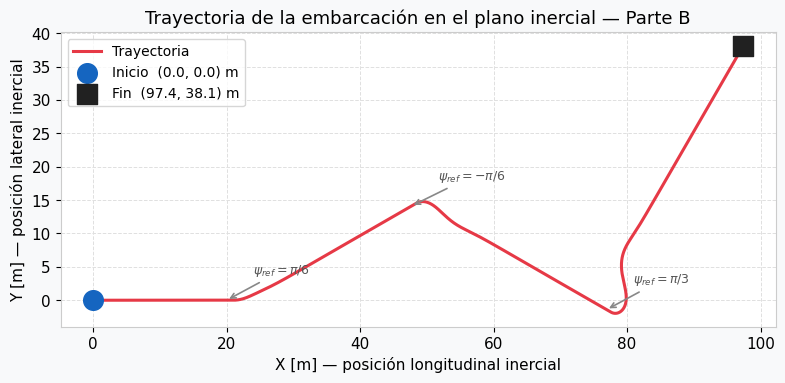

In [62]:
fig, ax = plt.subplots(figsize=(8, 8))

# Trayectoria
ax.plot(X_tray, Y_tray, '-', color=COL['tray'], lw=2.2, label='Trayectoria', zorder=2)

# Punto inicial (azul, grande)
ax.scatter(X_tray[0], Y_tray[0], s=200, color=COL['start'], zorder=5,
           label=f'Inicio  ({X_tray[0]:.1f}, {Y_tray[0]:.1f}) m')

# Punto final (negro, grande)
ax.scatter(X_tray[-1], Y_tray[-1], s=200, color=COL['end'], marker='s', zorder=5,
           label=f'Fin  ({X_tray[-1]:.1f}, {Y_tray[-1]:.1f}) m')

# Flechas indicando instantes de cambio de rumbo
cambios_t = [10, 25, 40]
cambios_ref = [r'$\psi_{ref}=\pi/6$', r'$\psi_{ref}=-\pi/6$', r'$\psi_{ref}=\pi/3$']
for tc, lbl in zip(cambios_t, cambios_ref):
    idx = np.argmin(np.abs(t1_u - tc))
    ax.annotate(lbl,
                xy=(X_tray[idx], Y_tray[idx]),
                xytext=(X_tray[idx] + 4, Y_tray[idx] + 4),
                fontsize=9, color='#555',
                arrowprops=dict(arrowstyle='->', color='#888', lw=1.2))

ax.set_xlabel('X [m] — posición longitudinal inercial')
ax.set_ylabel('Y [m] — posición lateral inercial')
ax.set_title('Trayectoria de la embarcación en el plano inercial — Parte B')
ax.legend(loc='upper left')
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

## B.4 · Efecto de los cambios de referencia sobre la trayectoria

| Intervalo | $\psi_{\text{ref}}$ | Efecto en trayectoria |
|-----------|---------------------|-----------------------|
| $0$–$10$ s | $0$ | La embarcación avanza en línea recta hacia $+X$ |
| $10$–$25$ s | $\pi/6 \approx 30°$ | Giro suave a la izquierda (hacia $+Y$) |
| $25$–$40$ s | $-\pi/6 \approx -30°$ | Giro a la derecha (hacia $-Y$), trayectoria más recta |
| $40$–$60$ s | $\pi/3 \approx 60°$ | Giro pronunciado a la izquierda, mayor curvatura |

Dado que el controlador tiene **dinámica transitoria** (~10 s de asentamiento), los cambios de rumbo
no se traducen en giros instantáneos: la trayectoria muestra curvaturas **suaves** en lugar de
esquinas, lo que es físicamente consistente con la inercia de la embarcación.

La velocidad lateral $v(t) \neq 0$ durante los transitorios produce un pequeño *sideslip*: la
dirección instantánea de movimiento difiere ligeramente de $\psi$, generando una leve
diferencia entre la trayectoria real y la que correspondería a seguimiento perfecto de rumbo.

## B.5 · Observaciones finales

**¿Se podría controlar $X$ e $Y$ directamente?**
Sí, pero cambiaría radicalmente el problema: pasaría de ser SISO (entrada $\tau_r$, salida $\psi$)
a un sistema MIMO con salidas $[X, Y]$. Además, las ecuaciones cinemáticas son **no lineales**
(aparecen $\cos\psi$ y $\sin\psi$), lo que requiere técnicas de control no lineal o linealización
en torno a trayectorias de referencia.

**¿La trayectoria es consistente con los cambios de rumbo?**
Sí: cada cambio en $\psi_{\text{ref}}$ se refleja en una curvatura de la trayectoria en la
dirección correcta, con la demora propia del transitorio del controlador.

**Limitaciones del esquema:**
- Sin control de posición, errores acumulados en $v(t)$ desplazan la trayectoria real respecto
  de la ideal.
- No hay retroalimentación de $X$ ni $Y$, por lo que perturbaciones externas (corrientes, viento)
  no se compensan en posición.
